# Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data

In [2]:
df_trader = pd.read_csv('historical_data.csv')
df_sentiment = pd.read_csv('fear_greed_index.csv')

In [3]:
df_trader.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
df_sentiment.tail(5)

,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


# 2. Date Standardization

In [8]:
# Extract date from trader timestamp (Handling 'DD-MM-YYYY' based on snippet)

df_trader['date_clean'] = pd.to_datetime(df_trader['Timestamp IST'], dayfirst=True).dt.strftime('%Y-%m-%d')
df_sentiment['date_clean'] = pd.to_datetime(df_sentiment['date']).dt.strftime('%Y-%m-%d')

# 3. Merge Datasets

In [9]:
merged_df = pd.merge(df_trader, df_sentiment, on='date_clean', how='inner')

# 4. Calculate Key Metrics

In [19]:
merged_df['is_win'] = merged_df['Closed PnL'] > 0

In [20]:
summary = merged_df.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    total_trades=('Trade ID', 'count'),
    win_rate=('is_win', 'mean'),
    avg_size_usd=('Size USD', 'mean')
).reset_index()

In [21]:
print("--- Performance by Market Sentiment ---")
print(summary)

--- Performance by Market Sentiment ---
  classification    avg_pnl  total_trades  win_rate  avg_size_usd
0   Extreme Fear  34.537862         21400  0.370607   5349.731843
1  Extreme Greed  67.892861         39992  0.464943   3112.251565
2           Fear  54.290400         61837  0.420768   7816.109931
3          Greed  42.743559         50303  0.384828   5736.884375
4        Neutral  34.307718         37686  0.396991   4782.732661


# 5. Quick Plot

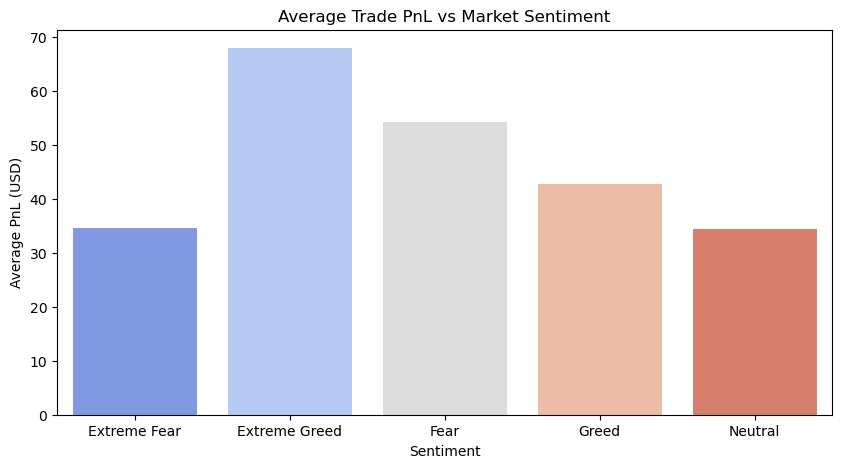

In [23]:
plt.figure(figsize=(10, 5))
sns.barplot(data=summary, x='classification', y='avg_pnl', hue='classification', palette='coolwarm', legend=False)
plt.title('Average Trade PnL vs Market Sentiment')
plt.ylabel('Average PnL (USD)')
plt.xlabel('Sentiment')
plt.savefig('sentiment_pnl_analysis.png')
plt.show()

# Directional Bias Analysis (Herd Mentality)

In [25]:
# Calculate Side breakdown per sentiment classification
side_analysis = merged_df.groupby(['classification', 'Side']).size().unstack(fill_value=0)
side_analysis['Total'] = side_analysis['BUY'] + side_analysis['SELL']
side_analysis['Buy %'] = (side_analysis['BUY'] / side_analysis['Total']) * 100
side_analysis['Sell %'] = (side_analysis['SELL'] / side_analysis['Total']) * 100

print("\n--- Trader Directional Bias by Sentiment ---")
print(side_analysis[['BUY', 'SELL', 'Buy %', 'Sell %']])


--- Trader Directional Bias by Sentiment ---
Side              BUY   SELL      Buy %     Sell %
classification                                    
Extreme Fear    10935  10465  51.098131  48.901869
Extreme Greed   17940  22052  44.858972  55.141028
Fear            30270  31567  48.951275  51.048725
Greed           24576  25727  48.855933  51.144067
Neutral         18969  18717  50.334342  49.665658


In [29]:
# Define the logical macro chronological sentiment sequence
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# ANALYSIS 1: DIRECTIONAL BIAS (HERD MENTALITY)

In [30]:
side_analysis = merged_df.groupby(['classification', 'Side']).size().unstack(fill_value=0).reindex(sentiment_order)
side_analysis['Total'] = side_analysis['BUY'] + side_analysis['SELL']
side_analysis['Buy %'] = (side_analysis['BUY'] / side_analysis['Total']) * 100
side_analysis['Sell %'] = (side_analysis['SELL'] / side_analysis['Total']) * 100

print("\n--- 📊 Directional Bias Matrix ---")
print(side_analysis[['BUY', 'SELL', 'Buy %', 'Sell %']])


--- 📊 Directional Bias Matrix ---
Side              BUY   SELL      Buy %     Sell %
classification                                    
Extreme Fear    10935  10465  51.098131  48.901869
Fear            30270  31567  48.951275  51.048725
Neutral         18969  18717  50.334342  49.665658
Greed           24576  25727  48.855933  51.144067
Extreme Greed   17940  22052  44.858972  55.141028


# Visualization 1: Stacked Bar Plot

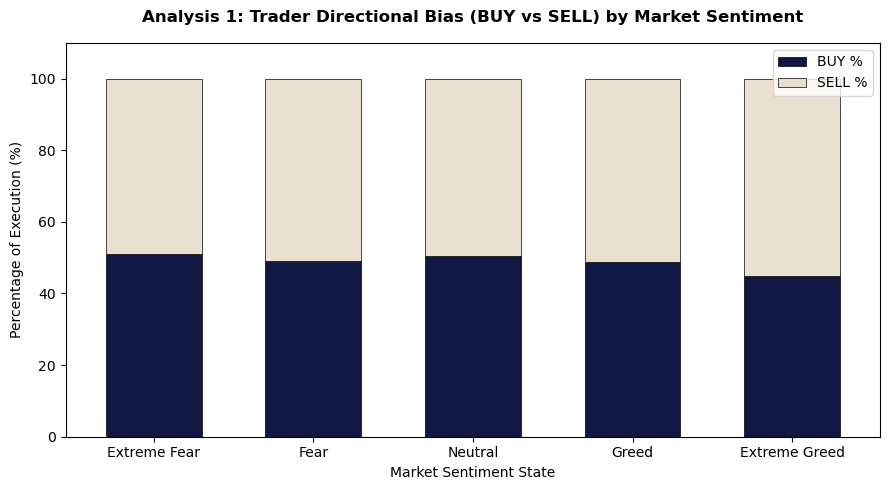

In [48]:
plt.rcParams['figure.figsize'] = [9, 5]
ax1 = side_analysis[['Buy %', 'Sell %']].plot(
    kind='bar', stacked=True, color=['#111844', '#EAE0CF'], width=0.6, edgecolor='black', linewidth=0.5
)
plt.title('Analysis 1: Trader Directional Bias (BUY vs SELL) by Market Sentiment', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Percentage of Execution (%)')
plt.xlabel('Market Sentiment State')
plt.xticks(rotation=0)
plt.ylim(0, 110)
plt.legend(['BUY %', 'SELL %'], loc='upper right')
plt.tight_layout()
plt.savefig('directional_bias.png')


# Fee vs. Profit Optimization (The "Neutral" Range Trap)

In [34]:
# Calculate Total Fees and Realized Profitability
fee_analysis = merged_df.groupby('classification').agg(
    total_pnl=('Closed PnL', 'sum'),
    total_fees=('Fee', 'sum'),
    avg_fee_per_trade=('Fee', 'mean')
).reset_index()

# Net PnL after subtracting transaction fees
fee_analysis['net_pnl'] = fee_analysis['total_pnl'] - fee_analysis['total_fees']

print("\n--- Fee Drag & Net Profit Analysis ---")
print(fee_analysis)


--- Fee Drag & Net Profit Analysis ---
  classification     total_pnl    total_fees  avg_fee_per_trade       net_pnl
0   Extreme Fear  7.391102e+05  23888.633939           1.116291  7.152216e+05
1  Extreme Greed  2.715171e+06  27030.665465           0.675902  2.688141e+06
2           Fear  3.357155e+06  92456.948674           1.495172  3.264698e+06
3          Greed  2.150129e+06  63098.691979           1.254372  2.087031e+06
4        Neutral  1.292921e+06  39374.268304           1.044798  1.253546e+06


# ANALYSIS 2: FEE VS. PROFIT OPTIMIZATION

In [35]:
fee_analysis = merged_df.groupby('classification').agg(
    total_pnl=('Closed PnL', 'sum'),
    total_fees=('Fee', 'sum')
).reindex(sentiment_order)

print("\n--- 📊 Fee Drag & Net Profit Matrix ---")
print(fee_analysis)


--- 📊 Fee Drag & Net Profit Matrix ---
                   total_pnl    total_fees
classification                            
Extreme Fear    7.391102e+05  23888.633939
Fear            3.357155e+06  92456.948674
Neutral         1.292921e+06  39374.268304
Greed           2.150129e+06  63098.691979
Extreme Greed   2.715171e+06  27030.665465


In [36]:
# Reshape data to fit seaborn grouped bar plot requirements
melted_fee = fee_analysis.reset_index().melt(
    id_vars='classification', value_vars=['total_pnl', 'total_fees'], var_name='Metric', value_name='Amount'
)

# Visualization 2: Grouped Bar Plot

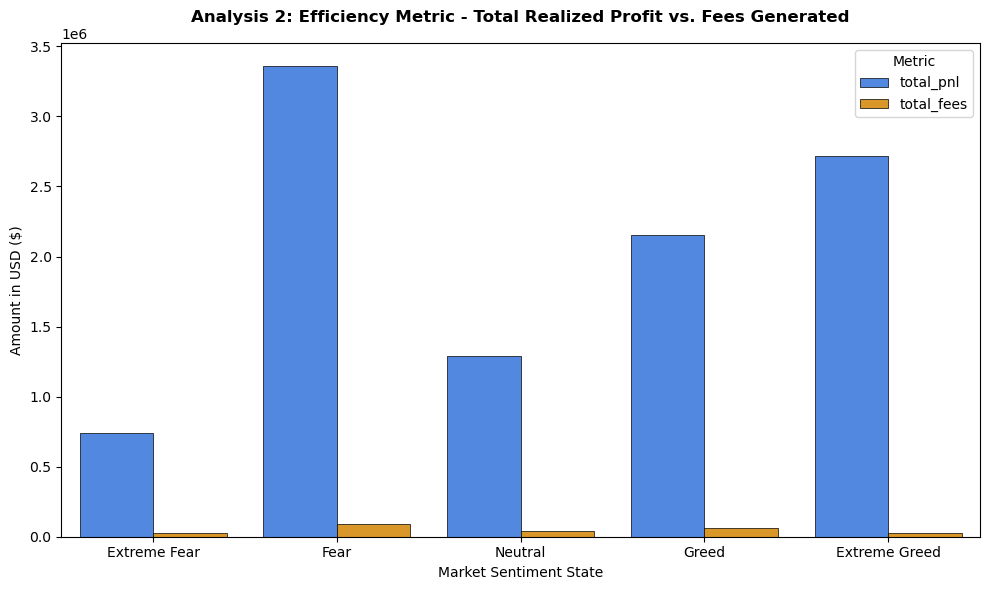

In [38]:
plt.rcParams['figure.figsize'] = [10, 6]
ax2 = sns.barplot(data=melted_fee, x='classification', y='Amount', hue='Metric', palette=['#3b82f6', '#f59e0b'], edgecolor='black', linewidth=0.5)
plt.title('Analysis 2: Efficiency Metric - Total Realized Profit vs. Fees Generated', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Amount in USD ($)')
plt.xlabel('Market Sentiment State')
plt.tight_layout()
plt.savefig('fee_profit_optimization.png')


# Risk Management & Drawdown Analysis

In [39]:
# Calculate worst-case metrics for risk management
risk_analysis = merged_df.groupby('classification').agg(
    max_loss=('Closed PnL', 'min'),
    max_win=('Closed PnL', 'max'),
    pnl_std=('Closed PnL', 'std') # Volatility of performance
).reset_index()

print("\n--- Risk & Volatility Profiles by Sentiment ---")
print(risk_analysis)


--- Risk & Volatility Profiles by Sentiment ---
  classification      max_loss       max_win      pnl_std
0   Extreme Fear  -31036.69194  115287.00000  1136.056091
1  Extreme Greed  -10259.46800   44223.45187   766.828294
2           Fear  -35681.74723  135329.09010   935.355438
3          Greed -117990.10410   74530.52371  1116.028390
4        Neutral  -24500.00000   48504.09555   517.122220


# ANALYSIS 3: RISK MANAGEMENT & DRAWDOWN RISK

In [40]:
risk_analysis = merged_df.groupby('classification').agg(
    max_loss=('Closed PnL', 'min'),
    pnl_std=('Closed PnL', 'std')
).reindex(sentiment_order).reset_index()

print("\n--- 📊 Risk & Performance Dispersion Profile ---")
print(risk_analysis)


--- 📊 Risk & Performance Dispersion Profile ---
  classification      max_loss      pnl_std
0   Extreme Fear  -31036.69194  1136.056091
1           Fear  -35681.74723   935.355438
2        Neutral  -24500.00000   517.122220
3          Greed -117990.10410  1116.028390
4  Extreme Greed  -10259.46800   766.828294


# Visualization 3a: Tail Risk Drawdown

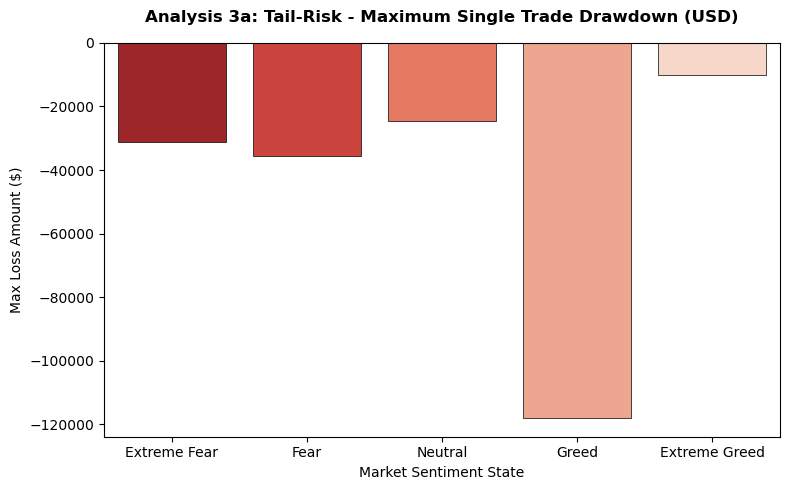

In [47]:
plt.rcParams['figure.figsize'] = [8, 5]
ax3a = sns.barplot(
    data=risk_analysis, 
    x='classification', 
    y='max_loss', 
    hue='classification',  
    palette='Reds_r', 
    legend=False,         
    edgecolor='black', 
    linewidth=0.5
)
plt.title('Analysis 3a: Tail-Risk - Maximum Single Trade Drawdown (USD)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Max Loss Amount ($)')
plt.xlabel('Market Sentiment State')
plt.tight_layout()
plt.savefig('risk_max_loss.png')

# Visualization 3b: PnL Performance Dispersion (Volatility)


🚀 All analytics complete! High-definition charts saved to your folder.


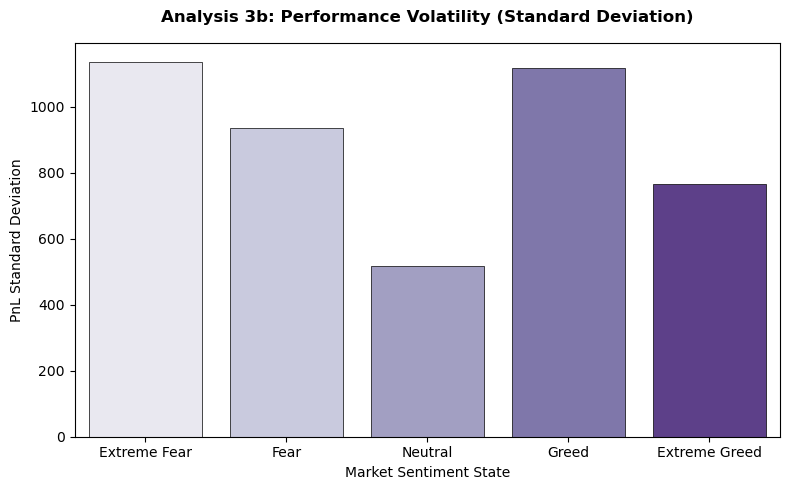

In [45]:
ax3b = sns.barplot(
    data=risk_analysis, 
    x='classification', 
    y='pnl_std', 
    hue='classification', 
    palette='Purples', 
    legend=False,          
    edgecolor='black', 
    linewidth=0.5
)
plt.title('Analysis 3b: Performance Volatility (Standard Deviation)', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('PnL Standard Deviation')
plt.xlabel('Market Sentiment State')
plt.tight_layout()
plt.savefig('risk_volatility.png')


print("\n🚀 All analytics complete! High-definition charts saved to your folder.")

Report Link: https://drive.google.com/drive/folders/1WHM9n1hPJbD3TurVFsaaBi-y3DzyWCaW?usp=sharing